Enter number of clusters (K): 3

Final Centroids:
[[4.5 9.5]
 [8.5 7.5]
 [1.5 2.5]]

Final Clusters:

Cluster 1
[[ 4 10]
 [ 5 10]
 [ 4  9]
 [ 5  9]]

Cluster 2
[[8 7]
 [8 8]
 [9 7]
 [9 8]]

Cluster 3
[[1 2]
 [1 3]
 [2 2]
 [2 3]]

Number of iterations: 3


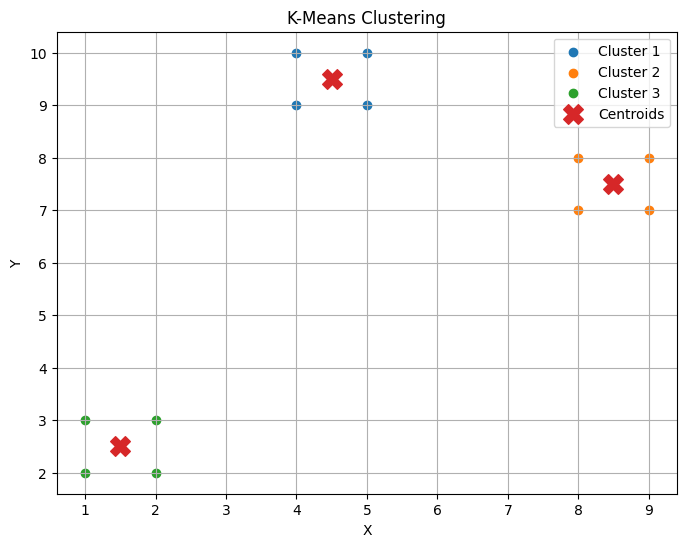

In [1]:
# K-Means Clustering Algorithm

import numpy as np
import matplotlib.pyplot as plt

# Dataset
X = np.array([
    [1, 2],
    [1, 3],
    [2, 2],
    [2, 3],
    [8, 7],
    [8, 8],
    [9, 7],
    [9, 8],
    [4, 10],
    [5, 10],
    [4, 9],
    [5, 9]
])

# Take number of clusters from user
k = int(input("Enter number of clusters (K): "))

# Random initialization
np.random.seed(42)

random_indices = np.random.choice(len(X), k, replace=False)
centroids = X[random_indices].astype(float)

# K-Means iterations
for iteration in range(100):

    # Calculate distance from each point to each centroid
    distances = np.zeros((len(X), k))

    for i in range(len(X)):
        for j in range(k):
            distances[i][j] = np.sqrt(
                np.sum((X[i] - centroids[j]) ** 2)
            )

    # Assign each point to nearest centroid
    labels = np.argmin(distances, axis=1)

    # Store old centroids
    old_centroids = centroids.copy()

    # Update centroids
    for j in range(k):
        points = X[labels == j]

        if len(points) > 0:
            centroids[j] = np.mean(points, axis=0)

    # Check convergence
    if np.allclose(centroids, old_centroids):
        break

# Display results
print("\nFinal Centroids:")
print(centroids)

print("\nFinal Clusters:")

for j in range(k):
    print("\nCluster", j + 1)
    print(X[labels == j])

print("\nNumber of iterations:", iteration + 1)

# Plot clusters
plt.figure(figsize=(8, 6))

for j in range(k):
    points = X[labels == j]
    plt.scatter(
        points[:, 0],
        points[:, 1],
        label="Cluster " + str(j + 1)
    )

# Plot centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("K-Means Clustering")
plt.legend()
plt.grid()
plt.show()